Dataset Shape: (284807, 31)


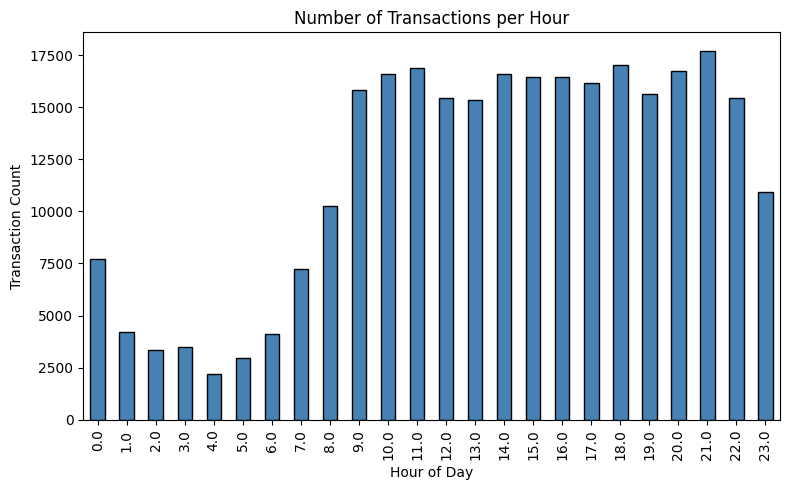


Top Transaction Hours:
Hour
21.0    17703
18.0    17039
11.0    16856
20.0    16756
10.0    16598
Name: Amount, dtype: int64

✔ Linear Regression Model Trained Successfully

Sample Predictions:
Actual: 30.3492 | Predicted: 38.0944
Actual: 40.0092 | Predicted: 51.6346
Actual: 3.1000 | Predicted: 9.0030
Actual: 0.0652 | Predicted: -8.8619
Actual: 0.0387 | Predicted: -8.9194


In [8]:
# =========================================================
# CREDIT CARD ANALYSIS - LINEAR REGRESSION (SIMPLIFIED)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# -------------------- LOAD DATASET --------------------
df = pd.read_csv("creditcard.csv")

print("Dataset Shape:", df.shape)

# -------------------- FEATURE ENGINEERING --------------------
df['Hour'] = (df['Time'] // 3600) % 24
df['AmountPerHour'] = df['Amount'] / (df['Hour'] + 1)

# =========================================================
# 1️⃣ DATA INSIGHT: PEAK TRANSACTION HOURS
# =========================================================

hour_counts = df.groupby("Hour")["Amount"].count()

plt.figure(figsize=(8,5))
hour_counts.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title("Number of Transactions per Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()

print("\nTop Transaction Hours:")
print(hour_counts.sort_values(ascending=False).head(5))

# =========================================================
# 2️⃣ LINEAR REGRESSION (MATRIX FORM)
# =========================================================

# Features (inputs)
X = df[['Hour', 'Amount']].values

# Target (output)
y = df['AmountPerHour'].values

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Add bias column (for intercept)
X_train_b = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test_b  = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

# Normal Equation (Linear Regression)
beta = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train

# Predictions
y_train_pred = X_train_b @ beta
y_test_pred  = X_test_b @ beta

print("\n✔ Linear Regression Model Trained Successfully")

# Show sample predictions only
print("\nSample Predictions:")
for i in range(5):
    print(f"Actual: {y_test[i]:.4f} | Predicted: {y_test_pred[i]:.4f}")

Original Dataset Shape: (284807, 31)

--- WITH DUPLICATES ---
Train RMSE: 32.873492024838
Test RMSE : 28.514831497750674
R2 Score  : 0.37240988614178594

--- WITHOUT DUPLICATES ---
Train RMSE: 32.82453284008066
Test RMSE : 29.039046289797245
R2 Score  : 0.3867781660767229

--- WITH OUTLIERS ---
Train RMSE: 32.873492024838
Test RMSE : 28.514831497750674
R2 Score  : 0.37240988614178594

--- WITHOUT OUTLIERS ---
Train RMSE: 7.455138646384178
Test RMSE : 7.7592168304199465
R2 Score  : 0.3233658948551523

================ FINAL TABLE ================
            Condition  Train RMSE  Test RMSE  R2 Score
0     With Duplicates   32.873492  28.514831  0.372410
1  Without Duplicates   32.824533  29.039046  0.386778
2       With Outliers   32.873492  28.514831  0.372410
3    Without Outliers    7.455139   7.759217  0.323366


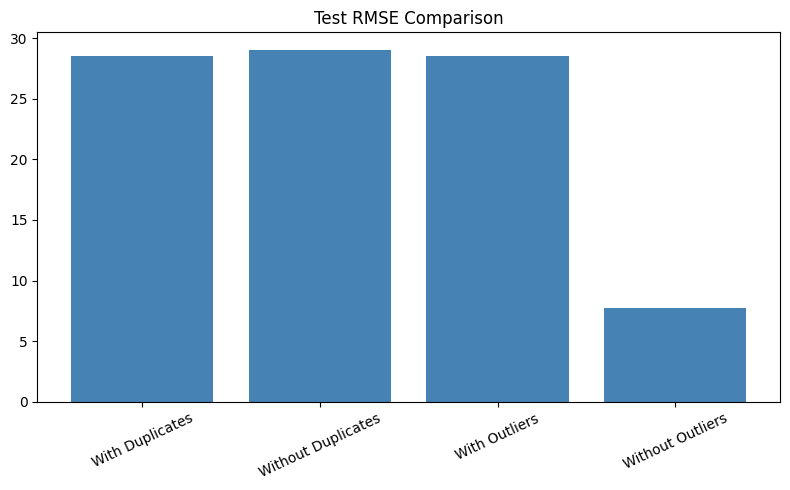

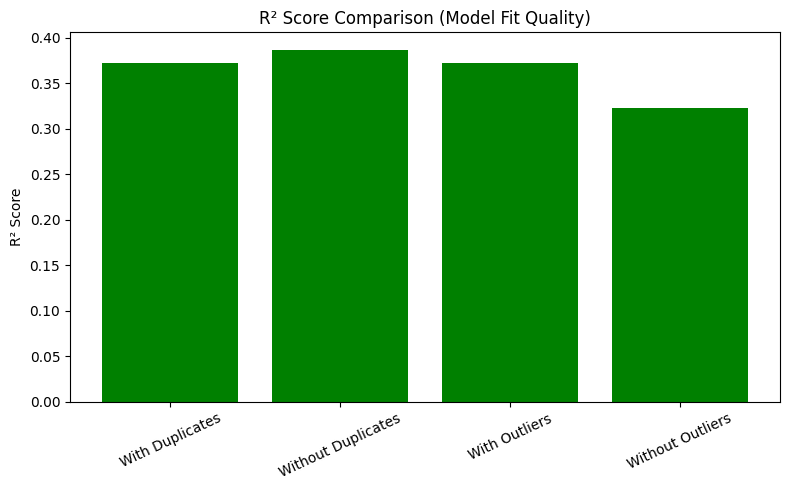

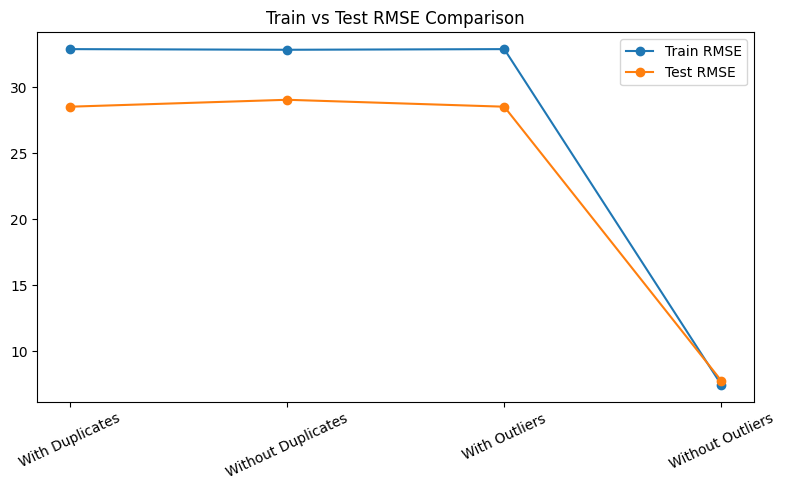


DONE ✔ Project Completed


In [ ]:
# =========================================================
# CREDIT CARD ANALYSIS - LINEAR REGRESSION + TIME INSIGHT
# WITH RMSE + R² COMPARISON VISUALIZATION
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# -------------------- LOAD DATASET --------------------
df = pd.read_csv("creditcard.csv")
print("Original Dataset Shape:", df.shape)

# -------------------- FEATURE ENGINEERING --------------------
df['Hour'] = (df['Time'] // 3600) % 24
df['AmountPerHour'] = df['Amount'] / (df['Hour'] + 1)

# =========================================================
# OUTLIER FUNCTION
# =========================================================
def remove_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[(data[col] >= lower) & (data[col] <= upper)]

# =========================================================
# LINEAR REGRESSION FUNCTION
# =========================================================
def run_model(data, label):

    X = data[['Hour', 'Amount']].values
    y = data['AmountPerHour'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # matrix form
    X_train_b = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
    X_test_b  = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

    # normal equation
    beta = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train

    # predictions
    y_train_pred = X_train_b @ beta
    y_test_pred  = X_test_b @ beta

    # metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2 = r2_score(y_test, y_test_pred)

    print("\n---", label, "---")
    print("Train RMSE:", train_rmse)
    print("Test RMSE :", test_rmse)
    print("R2 Score  :", r2)

    return train_rmse, test_rmse, r2

# =========================================================
# MODELS
# =========================================================
tr1, te1, r21 = run_model(df.copy(), "WITH DUPLICATES")

df_no_dup = df.drop_duplicates()
tr2, te2, r22 = run_model(df_no_dup, "WITHOUT DUPLICATES")

df_out = remove_outliers(df, 'Amount')
df_out = remove_outliers(df_out, 'Hour')

tr3, te3, r23 = run_model(df.copy(), "WITH OUTLIERS")
tr4, te4, r24 = run_model(df_out, "WITHOUT OUTLIERS")

# =========================================================
# FINAL TABLE
# =========================================================
results = pd.DataFrame({
    "Condition": [
        "With Duplicates",
        "Without Duplicates",
        "With Outliers",
        "Without Outliers"
    ],
    "Train RMSE": [tr1, tr2, tr3, tr4],
    "Test RMSE":  [te1, te2, te3, te4],
    "R2 Score":   [r21, r22, r23, r24]
})

print("\n================ FINAL TABLE ================")
print(results)

# =========================================================
# RMSE PLOT
# =========================================================
plt.figure(figsize=(8,5))
plt.bar(results['Condition'], results['Test RMSE'], color='steelblue')
plt.title("Test RMSE Comparison")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# =========================================================
# 🔥 R² PLOT (NEW ADDITION)
# =========================================================
plt.figure(figsize=(8,5))
plt.bar(results['Condition'], results['R2 Score'], color='green')
plt.title("R² Score Comparison (Model Fit Quality)")
plt.ylabel("R² Score")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# =========================================================
# TRAIN vs TEST RMSE
# =========================================================
plt.figure(figsize=(8,5))
plt.plot(results['Condition'], results['Train RMSE'], marker='o', label='Train RMSE')
plt.plot(results['Condition'], results['Test RMSE'], marker='o', label='Test RMSE')
plt.title("Train vs Test RMSE Comparison")
plt.legend()
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

print("\nDONE ✔ Project Completed")

Dataset Shape: (284807, 31)


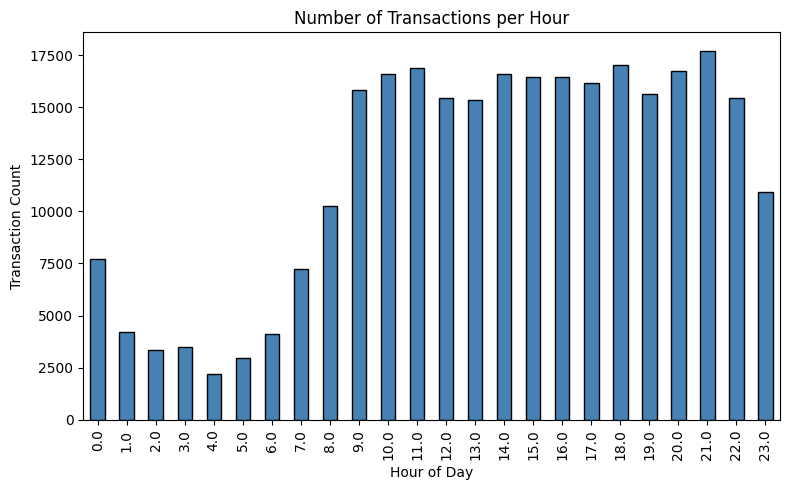


Top Transaction Hours:
Hour
21.0    17703
18.0    17039
11.0    16856
20.0    16756
10.0    16598
Name: Amount, dtype: int64

================ FINAL REGRESSION EQUATION ================
AmountPerHour = 
16.5295 + (-1.1608 * Hour) + (0.0943 * Amount) + (-0.0478 * V17)

✔ Linear Regression Model Built Successfully


In [1]:
# =========================================================
# CREDIT CARD ANALYSIS — MULTIPLE LINEAR REGRESSION
# Predicting AmountPerHour using Hour, Amount, V17
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# -------------------- LOAD DATASET --------------------
df = pd.read_csv("creditcard.csv")
print("Dataset Shape:", df.shape)

# -------------------- FEATURE ENGINEERING --------------------
df['Hour'] = (df['Time'] // 3600) % 24
df['AmountPerHour'] = df['Amount'] / (df['Hour'] + 1)

# =========================================================
# DATA INSIGHT — PEAK TRANSACTION HOURS
# =========================================================
hour_counts = df.groupby("Hour")["Amount"].count()

plt.figure(figsize=(8,5))
hour_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Number of Transactions per Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()

print("\nTop Transaction Hours:")
print(hour_counts.sort_values(ascending=False).head(5))

# =========================================================
# MULTIPLE LINEAR REGRESSION (MATRIX METHOD)
# =========================================================

# Features (inputs)
X = df[['Hour','Amount','V17']].values

# Target (output)
y = df['AmountPerHour'].values

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Add bias column (for β0)
X_train_b = np.hstack([np.ones((X_train.shape[0],1)), X_train])

# NORMAL EQUATION → β = (XᵀX)^(-1) Xᵀy
beta = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train

# =========================================================
# PRINT FINAL REGRESSION EQUATION
# =========================================================
b0, b1, b2, b3 = beta

print("\n================ FINAL REGRESSION EQUATION ================")
print("AmountPerHour = ")
print(f"{b0:.4f} + ({b1:.4f} * Hour) + ({b2:.4f} * Amount) + ({b3:.4f} * V17)")

print("\n✔ Linear Regression Model Built Successfully")